Consider a graph, where vertices are points on a plane and the lengths of the edges correspond to the Euclidean distance between these points.

Let us consider the following set of vertices
- A (1,3)
- B (6,2)
- C (4,4)
- D (2,5)
- E (0,7)
- F (-2,2)
- G (-3,-1)
- H (0, -4)

and the following edges:
    {A, B}, {B, C}, {C, D}, {D, E}, {E, F}, {F, G}, {G, H}, {H, A}, {D, F}, {A,C}, {F, A}

### Exercise 1.

Implement the adjacency list for this graph. Plot the graph using matplotlib.

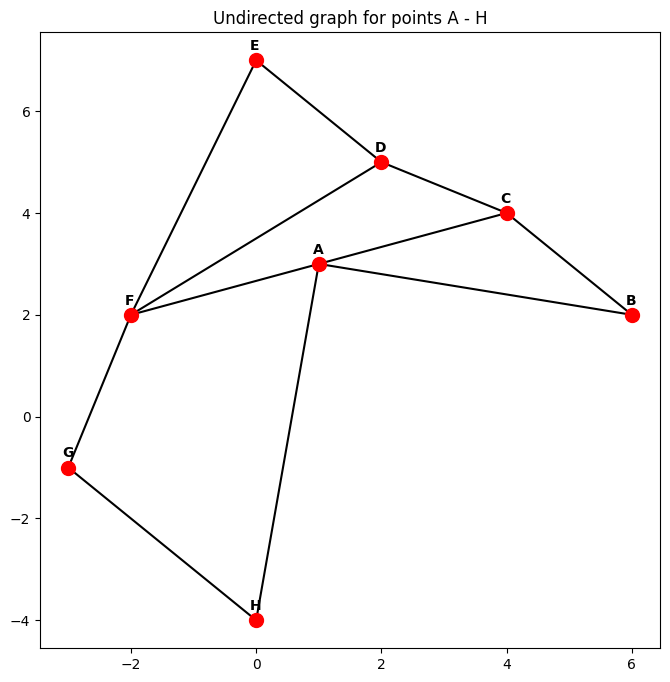

In [16]:
import matplotlib.pyplot as plt

# We have following vertices A, B, C, D, E, F, G, H with coordinates:
positions = {
    "A": (1, 3),
    "B": (6, 2),
    "C": (4, 4),
    "D": (2, 5),
    "E": (0, 7),
    "F": (-2, 2),
    "G": (-3, -1),
    "H": (0, -4)
}

# We have following edges {A, B}, {B, C}, {C, D}, {D, E}, {E, F}, {F, G}, {G, H}, {H, A}, {D, F}, {A,C}, {F, A}
adjacency_list = {
    "A": ["B", "H", "C", "F"],
    "B": ["A", "C"],
    "C": ["B", "D", "A"],
    "D": ["C", "E", "F"],
    "E": ["D", "F"],
    "F": ["E", "G", "A", "D"],
    "G": ["F", "H"],
    "H": ["G", "A"]
}

drawn_edges = set()

plt.figure(figsize = (8, 8))

# Draw the connections first
for node, neighbours in adjacency_list.items():
    for neighbour in neighbours:
        edge = tuple(sorted((node, neighbour)))
        if edge not in drawn_edges:
            p0 = positions[node]
            p1 = positions[neighbour]
            plt.plot([p0[0], p1[0]], [p0[1], p1[1]], color='black', zorder=1)
            drawn_edges.add(edge)

# Draw the points and their describtions
for key, p in positions.items():
    plt.plot(p[0], p[1], color='red', marker='o', ms = 10, zorder=2)
    plt.text(p[0] - 0.1, p[1] + 0.2, key, fontweight='bold', zorder=3)
    

plt.title('Undirected graph for points A - H')
plt.show()

### Exercise 2.

Use Dijkstra algorithm to find the shortest path between vertices E and H

In [17]:
vertices = {
    "A": (1, 3),
    "B": (6, 2),
    "C": (4, 4),
    "D": (2, 5),
    "E": (0, 7),
    "F": (-2, 2),
    "G": (-3, -1),
    "H": (0, -4)
}

edges = {
    "A": {"B", "H", "C", "F"},
    "B": {"A", "C"},
    "C": {"B", "D", "A"},
    "D": {"C", "E", "F"},
    "E": {"D", "F"},
    "F": {"E", "G", "A", "D"},
    "G": {"F", "H"},
    "H": {"G", "A"}
}

def euclidean_metric(A, B):
    return ((A[0] - B[0]) ** 2 + (A[1] - B[1]) ** 2) ** (1/2)


In [18]:
import heapq

def Dijkstra(V, E, start):
    distances = {j:float('inf') for j in V}
    distances[start] = 0
    predecessors = {j: None for j in V}
    queue = [(0, start)]
    visited = set()

    while queue:
        curr_dist, curr_vertex = heapq.heappop(queue)
        visited.add(curr_vertex)
        for neighbour in E[curr_vertex]:
            if neighbour in visited:
                continue
            else:
                dist_to_neighbour = euclidean_metric(V[curr_vertex], V[neighbour])
                if dist_to_neighbour + curr_dist < distances[neighbour]:
                    distances[neighbour] = dist_to_neighbour + curr_dist
                    predecessors[neighbour] = curr_vertex
                    heapq.heappush(queue, (dist_to_neighbour + curr_dist, neighbour))
        
    return predecessors

In [19]:
def get_path(predecessors, start, stop):
    path = []
    current = stop
    while current is not None:
        path.append(current)
        current = predecessors[current]
    path.reverse()
    if path[0] == start:
        return path
    else:
        return []

In [20]:
preds = Dijkstra(vertices, edges, 'E')
print(get_path(preds, 'E', 'H'))

['E', 'F', 'G', 'H']


### Exercise 3.
Plot the resulting path on a picture.

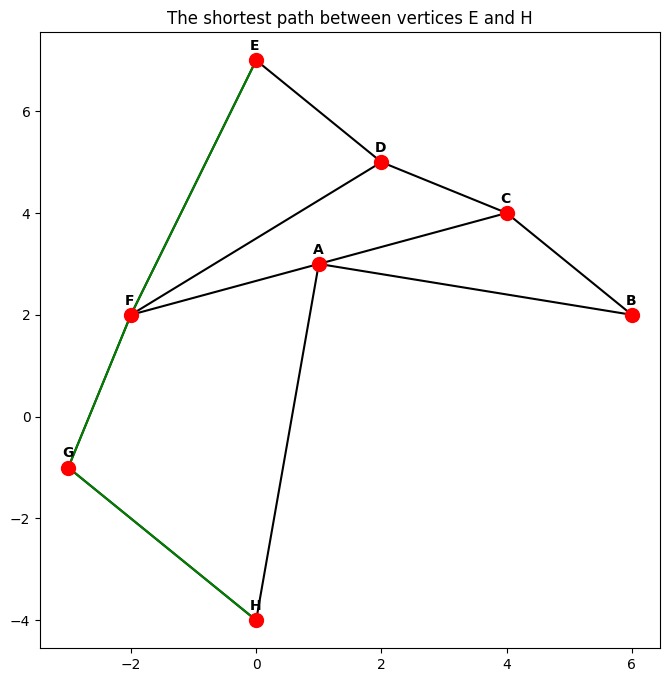

In [21]:
import matplotlib.pyplot as plt

drawn_edges = set()

plt.figure(figsize = (8, 8))

# Draw the connections first
for node, neighbours in adjacency_list.items():
    for neighbour in neighbours:
        edge = tuple(sorted((node, neighbour)))
        if edge not in drawn_edges:
            p0 = positions[node]
            p1 = positions[neighbour]
            plt.plot([p0[0], p1[0]], [p0[1], p1[1]], color='black', zorder=1)
            drawn_edges.add(edge)

# Draw the path between two vertices E and H
preds = Dijkstra(vertices, edges, 'E')
path = get_path(preds, 'E', 'H')
for i in range(len(path) - 1):
        edge = tuple(sorted((path[i], path[i + 1])))
        p0 = positions[edge[0]]
        p1 = positions[edge[1]]
        plt.plot([p0[0], p1[0]], [p0[1], p1[1]], color='green', zorder=2)

# Draw the points and their describtions
for key, p in positions.items():
    plt.plot(p[0], p[1], color='red', marker='o', ms = 10, zorder=3)
    plt.text(p[0] - 0.1, p[1] + 0.2, key, fontweight='bold', zorder=4)
    

plt.title('The shortest path between vertices E and H')
plt.show()